# 02 -- Exploratory Data Analysis (cleaned signals)

Evidence, not assumptions: this notebook shows *why* the model needs
scale-invariant features (operating points differ by orders of magnitude
across runs) and gives the standard EDA views -- correlation heatmap,
distributions, box plots -- before any feature engineering happens.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P

import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clean = pd.read_parquet(P.ART_DIR / "clean_runs.parquet")
common = json.loads((P.ART_DIR / "common_signals.json").read_text())
print("Common signals used everywhere downstream:", common)

Common signals used everywhere downstream: ['pressure', 'current', 'vdc', 'vac']


## Per-run operating point (evaluation region, t >= fault time)

Absolute levels differ by orders of magnitude across runs -> the model must rely on scale-invariant + baseline-deviation features, not raw levels.

In [2]:
ev = clean[clean["time"] >= P.FAULT_T]
tbl = ev.groupby("run_id")[common].agg(["mean", "max"]).round(3)
tbl

pressure            current           \
                                         mean       max     mean      max   
run_id                                                                      
Healthy Data 3                          1.013     1.013    5.190    5.529   
Leakage_factor                       1876.149  1936.128  221.792  228.798   
Medium_FlexibleShaft_Fault              0.549     1.021   27.503   36.436   
MildFlexible_shaft                      0.026     0.044   25.430   27.912   
disp1_fault(0.5)                        1.310     1.478   28.014   36.431   
disp2_fault(0.3)                        3.923     7.144   27.915   36.430   
disp3_fault(0.2)                        2.290     6.376   27.923   36.436   
leakage_fault(0.5)                   3611.871  4126.073   23.054   23.285   
leakage_fault(1.0)                   1897.485  1936.358   23.163   23.285   
pump_disp(st-0.5)                      22.045    61.096   27.941   36.431   
simplified_generator_fault             36.361    47.340   28.025   36.369   
simplifiied-generator-fault             0.185     0.493   27.107   33.844   
simplifiied-generator-fault(st-0.5)     0.128     0.493   27.392   34.989   

                                         vdc               vac           
                                        mean      max     mean      max  
run_id                                                                   
Healthy Data 3                        25.951   27.645   -0.888  603.099  
Leakage_factor                       116.012  116.424    0.187  177.653  
Medium_FlexibleShaft_Fault           137.513  182.180   -3.679  186.383  
MildFlexible_shaft                   127.149  139.558    0.352  178.677  
disp1_fault(0.5)                     140.071  182.155   -1.378  186.380  
disp2_fault(0.3)                     139.575  182.152   -3.629  186.392  
disp3_fault(0.2)                     139.617  182.181    0.348  186.395  
leakage_fault(0.5)                   115.271  116.423   -1.923  177.621  
leakage_fault(1.0)                   115.816  116.424   -0.035  177.655  
pump_disp(st-0.5)                    139.703  182.155   -0.768  186.380  
simplified_generator_fault           140.127  181.843  140.127  181.843  
simplifiied-generator-fault          135.534  169.218    1.315  187.559  
simplifiied-generator-fault(st-0.5)  136.962  174.945    0.760  187.559

## Correlation heatmap (raw common signals)

Checked for redundancy between the 4 common channels themselves. This is EDA evidence, not a feature-removal step -- feature-level redundancy is checked again in notebook 04 after engineering.

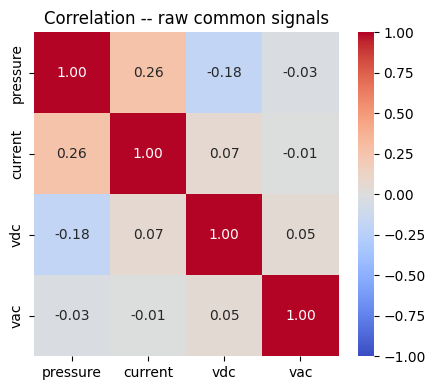

In [3]:
corr = clean[common].corr()
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation -- raw common signals")
plt.tight_layout(); plt.show()

## Distributions (histograms)

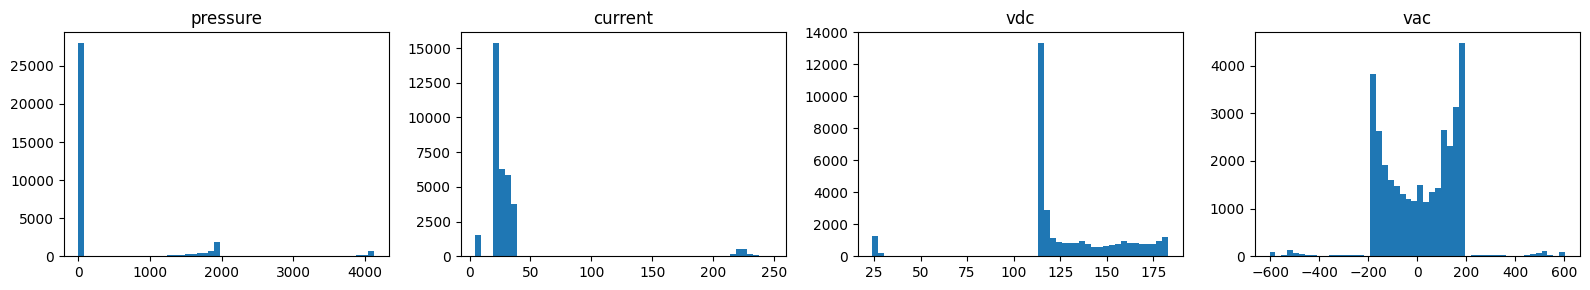

In [4]:
fig, axes = plt.subplots(1, len(common), figsize=(4 * len(common), 3))
for ax, c in zip(axes, common):
    ax.hist(clean[c].dropna(), bins=50)
    ax.set_title(c)
plt.tight_layout(); plt.show()

## Box plots (per class, outlier visualization)

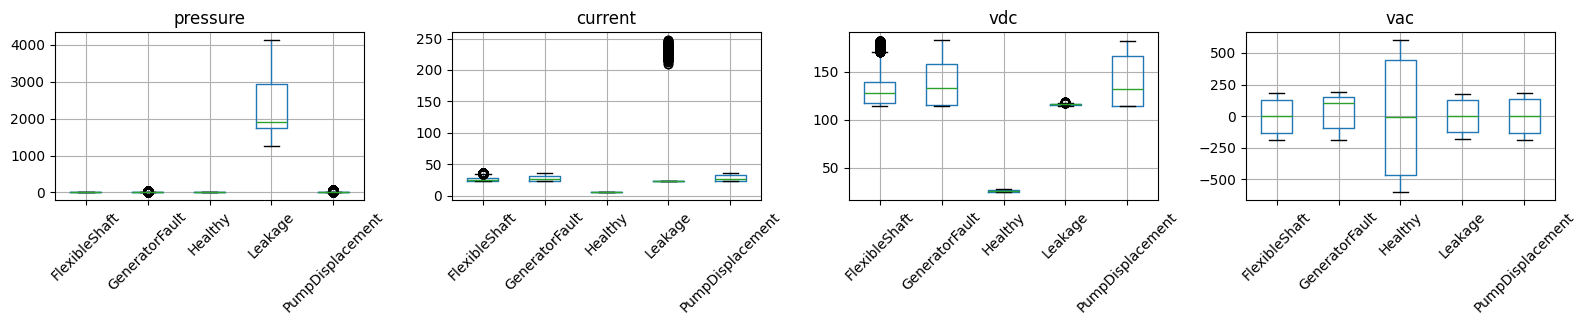

In [5]:
fig, axes = plt.subplots(1, len(common), figsize=(4 * len(common), 3.5))
for ax, c in zip(axes, common):
    clean.boxplot(column=c, by="label", ax=ax, rot=45)
    ax.set_title(c); ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout(); plt.show()